Some of the package imports and functions will not be relevant for you, but I have left my full startup intact so you can look through it and use whatever you like.

Because I don't know exactly what your data format looks like I have avoided including spaces for you to import specific files and instead have tried to provide instructions at the neccesary stages. The next two cells are just package imports and custom functions which you can ignore reading through for now

In [22]:
# Core scientific libraries
import os
import random
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl

# NetCDF file handling
#import netCDF4 as nc

# Image processing
from skimage.io import imread, imshow, concatenate_images
from skimage.transform import resize
from skimage.morphology import label

# Machine learning and utilities
from sklearn.model_selection import train_test_split, KFold
from tqdm import tqdm_notebook, tnrange
from itertools import chain

# TensorFlow / Keras (modern import structure)
import tensorflow as tf
from keras.models import Model, Sequential, load_model
from keras.layers import (
    Input, Dense, Dropout, Activation, BatchNormalization, Flatten,
    Lambda, RepeatVector, Reshape, Conv1D, Conv2D, Conv2DTranspose,
    MaxPooling2D, GlobalMaxPool2D, concatenate, add
)
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam
from keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import img_to_array, array_to_img, load_img


# Optional: Set plotting style and fonts
font = {
    'family': 'sans-serif',  # or 'DejaVu Sans'
    'weight': 'bold',
    'size': 22
}
mpl.rc('font', **font)


In [23]:
from keras import backend as K
smooth = 1e-12
def jaccard_coef(y_true, y_pred):
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])  # per image
    union = tf.reduce_sum(y_true + y_pred, axis=[1, 2, 3])
    jac = (intersection + smooth) / (union - intersection + smooth)
    return tf.reduce_mean(jac)  # average over batch


def jaccard_coef_int(y_true, y_pred):
    y_pred_pos = K.round(K.clip(y_pred, 0, 1))

    intersection = K.sum(y_true * y_pred_pos, axis=[0, -1, -2])
    sum_ = K.sum(y_true + y_pred_pos, axis=[0, -1, -2])

    jac = (intersection + smooth) / (sum_ - intersection + smooth)

    return K.mean(jac)


def jaccard_coef_loss(y_true, y_pred):
    jac = tf.clip_by_value(jaccard_coef(y_true, y_pred), 1e-6, 1.0)  # avoid log(0)
    return -tf.math.log(jac) + tf.keras.backend.binary_crossentropy(y_true, y_pred)


def select_plume_location(noise, plume_shape, nan_threshold = 0.1):
    success = 0
    while success == 0:
        noise_shape = noise.shape
 #       print(noise)
        coord_range = np.subtract(noise_shape,plume_shape)
        x = np.random.randint(0,coord_range[0])
        y = np.random.randint(0,coord_range[1])

        #location selected now check to make sure chosen range is in area with data
        selected_noise_area = noise[x:x+plume_shape[0],y:y+plume_shape[1]]
        nan_sum = 0
        nanmap = np.zeros(selected_noise_area.shape)
        for j in range(plume_shape[0]):
            for k in range(plume_shape[1]):
                if np.isnan(selected_noise_area[j,k])==True:
                    nan_sum = nan_sum+1
                    nanmap[j,k]= 1
        nan_fraction = nan_sum/(plume_shape[0]*plume_shape[1])
        if nan_fraction<nan_threshold:
            success = 1
    return [x,y,nanmap]

def get_background_images_single_file(noise,num_of_imgs):
    out = np.zeros((num_of_imgs,128,128))
    for j in range(num_of_imgs):
        x,y,nanmap = select_plume_location(noise, plume_shape = (128,128), nan_threshold = 0.1)
        out[j] = noise[x:x+128,y:y+128]
    return out

def get_background_images_multiple_files(directory, imgs_per_file, date):

    counter = 0
    for file in os.listdir(directory):
        if ".npy" in file:
            counter = counter+1
    out = np.zeros((counter*imgs_per_file,128,128))
    counter = 0
    for file in os.listdir(directory):
        if ".npy" in file:
            print(counter)
            noise_temp = np.load(directory+file)
            out_temp = get_background_images_single_file(noise_temp, imgs_per_file)
            out[counter*imgs_per_file:(counter*imgs_per_file)+imgs_per_file] = out_temp
            counter = counter+1
    np.save(path_hd+ 'background_c1_imgs_' +str(imgs_per_file)+'_per_file_'+str(date), out)
    return out


def conv2d_block(input_tensor, n_filters, kernel_size=3, batchnorm=True):
    # first layer
    x = Conv2D(filters=n_filters, kernel_size=(kernel_size, kernel_size), kernel_initializer="he_normal",
               padding="same")(input_tensor)
    if batchnorm:
        x = BatchNormalization()(x)
    x = Activation("relu")(x)
    # second layer
    x = Conv2D(filters=n_filters, kernel_size=(kernel_size, kernel_size), kernel_initializer="he_normal",
               padding="same")(x)
    if batchnorm:
        x = BatchNormalization()(x)
    x = Activation("relu")(x)
    return x

def get_unet(input_img, n_filters=16, dropout=0.5, batchnorm=True):
 #   contracting path
    c1 = conv2d_block(input_img, n_filters=n_filters*1, kernel_size=3, batchnorm=batchnorm)
    p1 = MaxPooling2D((2, 2)) (c1)
    p1 = Dropout(dropout*0.5)(p1)

    c2 = conv2d_block(p1, n_filters=n_filters*2, kernel_size=3, batchnorm=batchnorm)
    p2 = MaxPooling2D((2, 2)) (c2)
    p2 = Dropout(dropout)(p2)

    c3 = conv2d_block(p2, n_filters=n_filters*4, kernel_size=3, batchnorm=batchnorm)
    p3 = MaxPooling2D((2, 2)) (c3)
    p3 = Dropout(dropout)(p3)

    c4 = conv2d_block(p3, n_filters=n_filters*8, kernel_size=3, batchnorm=batchnorm)
    p4 = MaxPooling2D(pool_size=(2, 2)) (c4)
    p4 = Dropout(dropout)(p4)

    c5 = conv2d_block(p4, n_filters=n_filters*16, kernel_size=3, batchnorm=batchnorm)

    # expansive path
    u6 = Conv2DTranspose(n_filters*8, (3, 3), strides=(2, 2), padding='same') (c5)
    u6 = concatenate([u6, c4])
    u6 = Dropout(dropout)(u6)
    c6 = conv2d_block(u6, n_filters=n_filters*8, kernel_size=3, batchnorm=batchnorm)

    u7 = Conv2DTranspose(n_filters*4, (3, 3), strides=(2, 2), padding='same') (c6)
    u7 = concatenate([u7, c3])
    u7 = Dropout(dropout)(u7)
    c7 = conv2d_block(u7, n_filters=n_filters*4, kernel_size=3, batchnorm=batchnorm)

    u8 = Conv2DTranspose(n_filters*2, (3, 3), strides=(2, 2), padding='same') (c7)
    u8 = concatenate([u8, c2])
    u8 = Dropout(dropout)(u8)
    c8 = conv2d_block(u8, n_filters=n_filters*2, kernel_size=3, batchnorm=batchnorm)

    u9 = Conv2DTranspose(n_filters*1, (3, 3), strides=(2, 2), padding='same') (c8)
    u9 = concatenate([u9, c1], axis=3)
    u9 = Dropout(dropout)(u9)
    c9 = conv2d_block(u9, n_filters=n_filters*1, kernel_size=3, batchnorm=batchnorm)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)
    model = Model(inputs=[input_img], outputs=[outputs])
    return model

def random_plume_rotation(plumes):
    out = np.zeros(plumes.shape)
    print(out.shape)
    for j in range(len(plumes)):
        out[j] = plumes[j]
        rand = np.random.randint(1,5)
        plume_rot = np.rot90(plumes[j,0,:,:],rand)
        out[j,0,:,:] = plume_rot
        if rand==1:
            out[j,1,:,:] = -plumes[j,2,:,:]
            out[j,2,:,:] = plumes[j,1,:,:]
        if rand==2:
            out[j,1,:,:] = -plumes[j,1,:,:]
            out[j,2,:,:] = -plumes[j,2,:,:]
        if rand==3:
            out[j,1,:,:] = plumes[j,2,:,:]
            out[j,2,:,:] = -plumes[j,1,:,:]
    return out

def get_corr_factor(rate_kg_h, rate_sim = 12):
#    rate_sim = 12 #units/s #take as mols/s
    molar_mass = 0.016043 #kg/mol of methane
    rate_mols_s = rate_kg_h/molar_mass/3600 #mols/s
    corr_factor = rate_mols_s/rate_sim
    return corr_factor


def get_full_imgs(back,plumes,sr_range):
    out = np.zeros(back.shape)
    sr = np.random.uniform(sr_range[0],sr_range[1],len(back))
    for j in range(len(back)):
        c_fac = get_corr_factor(sr[j])
        plume = plumes[j]/(25**2)*c_fac
#        out_masks = plume
        out[j] = plume+back[j]
        out[j] = np.nan_to_num(out[j],nan=0)
    return out, sr #out_masks

def get_full_imgs_with_winds(back,plumes,sr_range):
    out = np.zeros(plumes.shape)
    print(out.shape)

    sr = np.random.uniform(sr_range[0],sr_range[1],len(back))

    out[:,1,:,:] = plumes[:,1,:,:]
    out[:,2,:,:] = plumes[:,2,:,:]
    for j in range(len(back)):
        c_fac = get_corr_factor(sr[j])
        plume = plumes[j,0,:,:]/(25**2)*c_fac
#        out_masks = plume
        out[j,0,:,:] = plume+back[j]
        out[j,0,:,:] = np.nan_to_num(out[j,0,:,:],nan=0)
    return out, sr #out_masks

def get_sr_cnn_deep(input_img, n_filters=16, dropout=0.5, batchnorm = True):
    c1 = conv2d_block(input_img, n_filters=n_filters*1, kernel_size=3, batchnorm=batchnorm)
    p1 = MaxPooling2D((2, 2)) (c1)
    p1 = Dropout(dropout*0.5)(p1)

    c2 = conv2d_block(p1, n_filters=n_filters*2, kernel_size=3, batchnorm=batchnorm)
    p2 = MaxPooling2D((2, 2)) (c2)
    p2 = Dropout(dropout)(p2)

    c3 = conv2d_block(p2, n_filters=n_filters*4, kernel_size=3, batchnorm=batchnorm)
    p3 = MaxPooling2D((2, 2)) (c3)
    p3 = Dropout(dropout)(p3)

    c4 = conv2d_block(p3, n_filters=n_filters*8, kernel_size=3, batchnorm=batchnorm)
    p4 = MaxPooling2D(pool_size=(2, 2)) (c4)
    p4 = Dropout(dropout)(p4)

    c5 = conv2d_block(p4, n_filters=n_filters*16, kernel_size=3, batchnorm=batchnorm)

    f1 = Flatten()(c5)
    d1 = Dense(32, activation = 'relu')(f1)
    d1 = Dense(16, activation = 'relu')(d1)

    outputs = Dense(1, activation = 'relu')(d1)
    model = Model(inputs=[input_img], outputs=[outputs])
    return model

def get_detector_cnn_deep(input_img, n_filters=16, dropout=0.5, batchnorm = True):
    c1 = conv2d_block(input_img, n_filters=n_filters*1, kernel_size=3, batchnorm=batchnorm)
    p1 = MaxPooling2D((2, 2)) (c1)
    p1 = Dropout(dropout*0.5)(p1)

    c2 = conv2d_block(p1, n_filters=n_filters*2, kernel_size=3, batchnorm=batchnorm)
    p2 = MaxPooling2D((2, 2)) (c2)
    p2 = Dropout(dropout)(p2)

    c3 = conv2d_block(p2, n_filters=n_filters*4, kernel_size=3, batchnorm=batchnorm)
    p3 = MaxPooling2D((2, 2)) (c3)
    p3 = Dropout(dropout)(p3)

    c4 = conv2d_block(p3, n_filters=n_filters*8, kernel_size=3, batchnorm=batchnorm)
    p4 = MaxPooling2D(pool_size=(2, 2)) (c4)
    p4 = Dropout(dropout)(p4)

    c5 = conv2d_block(p4, n_filters=n_filters*16, kernel_size=3, batchnorm=batchnorm)

    f1 = Flatten()(c5)
    d1 = Dense(32, activation = 'relu')(f1)
    d1 = Dense(16, activation = 'relu')(d1)

    outputs = Dense(1, activation = 'sigmoid')(d1)
    model = Model(inputs=[input_img], outputs=[outputs])
    return model

vert_bounds = (80,150)
hor_bounds = (200,230)
def rotate_winds(u,v,rot_deg):
    angle = np.arctan2(v,u)
    rot_rad = rot_deg*np.pi/180
    if angle<0:
        angle = 2*np.pi+angle

    mag = (u**2+v**2)**(1/2)
    u_new = np.cos(angle+rot_rad)*mag

    v_new = np.sin(angle+rot_rad)*mag

    return([u_new,v_new])


def get_plumes(plume_array, num_of_plumes):
    plume_set = np.asarray(random.choices(plume_array, k = num_of_plumes))
    print(plume_set.shape)
    out = np.zeros((len(plume_set),3,128,128))
    for j in range(len(plume_set)):
        vert_start = np.random.randint(vert_bounds[0],vert_bounds[1])
        vert_end = vert_start+128
        hor_start = np.random.randint(hor_bounds[0],hor_bounds[1])
        hor_end = hor_start+128
#        print(vert_start,vert_end, hor_start, hor_end)
#        print(plume_set[j,0,vert_start:vert_end, hor_start:hor_end].shape)
        out[j,0,:,:] = plume_set[j,0,vert_start:vert_end, hor_start:hor_end]
        rot_deg = np.random.randint(1,360)
        out[j,0,:,:] = sp.ndimage.rotate(out[j,0,:,:],rot_deg, axes=(0,1), reshape=False)
        winds = rotate_winds(plume_set[j,1,0,0], plume_set[j,2,0,0], rot_deg)

        out[j,1,:,:] = winds[0]
        out[j,2,:,:] = winds[1]
    return(out)

def jac_simple(y_pred,y_true):
    y_pred = y_pred>0.5
    intersection = np.sum(y_pred & y_true, (1,2))
    unity = np.sum(y_pred | y_true, (1,2))
    jac = intersection/unity
    return jac

def jac_simple_weighted(y_pred,y_true):
    y_pred = y_pred>0.5
    intersection = np.sum(y_pred & y_true, (1,2))
    unity = np.sum(y_pred | y_true, (1,2))
    plume

    jac = intersection/unity
    return jac

def get_enhancement_captured(plume_original, pred_mask):
    total_enhancement = np.sum(plume_original, (1,2))

    pred_enh = np.sum(plume_original*pred_mask, (1,2))

    fraction_total_enhancement = pred_enh/total_enhancement
    return fraction_total_enhancement

#IME Funcs
m_a = 0.00289647 #mass of dry air kg/mol
m_ch4 = 0.01614 #mass of methane kg/mol
omega_a = 1.03*(10**4) #column mass of dry air kg/m2


def get_IME(img,mask, a = 25**2):
    not_mask = np.logical_not(mask)
    back_img = img*not_mask
    back_vals = back_img[back_img != False]
    back_vals = back_vals[back_vals != np.nan]

#    print(back_vals)
    background = np.median(back_vals)
    #testing
#    background = np.percentile(back_vals,80)
#    background = 0

    #testing
    delta_x = (img - background)*mask
 #   print(np.sum(delta_x))
    IME = np.sum(delta_x*m_ch4*a)
    return IME

def get_ueff(u10,v10):
    #This is the approach use by varon et al but may need to recalibrate
    u10 = np.mean(u10)
    v10 = np.mean(v10)
    u = (u10**2+v10**2)**(1/2)
    ueff = np.log(u)+0.5
#    print('ueff = '+str(ueff))
    return ueff

def get_source_rate(img,mask,u10,v10, a = 25**2):
    L = (np.sum(mask)*a)**(1/2)
    IME = get_IME(img,mask,a)
    u_eff = get_ueff(u10,v10)
    Q = u_eff/L*IME/(10**3)*3600 #t/h
#    print('Q = '+str(Q))
    return Q

def get_source_rate_u10(img,mask,U10,ueff_slope = 0.18801551, ueff_int = 0.8801000582013674, a = 25**2):
    L = (np.sum(mask)*a)**(1/2)
    IME = get_IME(img,mask,a)
#    u_eff = np.log(U10)+0.5
    u_eff = ueff_slope*U10+ueff_int
#    u_eff =1
#    print(u_eff,L, IME)
    Q = u_eff/L*IME/(10**3)*3600 #t/h
#    print('Q = '+str(Q))
    return Q

def ueff_calibration(img,mask, Q,a = 25**2):
    Q = Q/3600
#    print(Q)
    L = (np.sum(mask)*a)**(1/2)
    IME = get_IME(img,mask,a)
#    print(IME)

    ueff = Q*L/IME
    return ueff

def get_ime_out(x_10, y_10):
    IME = np.zeros(len(x_10))
    u10 = np.zeros(len(x_10))

    for j in range(len(x_10)):
        IME[j] = get_IME(x_10[j,:,:,0],x_10[j,:,:,2]>0.5)
        u10[j] = np.mean(x_10[j,:,:,1])

    non_zero_winds_loc = np.where(u10>0)
    IME = IME[non_zero_winds_loc]
    u10 = u10[non_zero_winds_loc]
    x_10 = x_10[non_zero_winds_loc]
    y_10 = y_10[non_zero_winds_loc]

    sr = np.zeros(len(x_10))

    for j in range(len(x_10)):
        sr[j] = get_source_rate_u10(x_10[j,:,:,0],x_10[j,:,:,2]>0.5, u10[j])

    return sr*1000,y_10, non_zero_winds_loc



Okay so the first thing we need to do is import your data and get it formatted in a way that will play nice with our model.

You will need two arrays of data:

(1) Methane enhancement fields with even, equivalent horizontal and vertical dimensions (I recommend modest
dimensions like 128 or 64 to start out to keep training time quick)

(2) Binary mask arrays of the plume pixels in each image

In [42]:
data = np.load("augmented_test_masks_1000_kg_h.npy")

# /Users/aj/Downloads/uplume_traintest_images.npy
# /Users/aj/Downloads/uplume_traintest_masks.npy

imgs_path = r"uplume_traintest_images.npy"
masks_path = r"uplume_traintest_masks.npy"

imgs = np.load(imgs_path)
masks = np.load(masks_path)

# Basic inspection
print("Images shape:", imgs.shape)
print("Masks shape:", masks.shape)



Images shape: (6869, 128, 128, 2)
Masks shape: (6869, 128, 128)


In [25]:
# One sample's shape
print("Image shape:", imgs[1].shape)

# Data type of the array
print("Image dtype:", imgs.dtype)

# Min, max, mean, and standard deviation
print("Min:", np.min(imgs))
print("Max:", np.max(imgs))
print("Mean:", np.mean(imgs))
print("Std dev:", np.std(imgs))

# If you want to check per channel (e.g. enhancement vs wind):
print("Enhancement channel stats:")
print("  Min:", np.min(imgs[:, :, :, 0]))
print("  Max:", np.max(imgs[:, :, :, 0]))
print("  Mean:", np.mean(imgs[:, :, :, 0]))

print("Wind channel stats:")
print("  Min:", np.min(imgs[:, :, :, 1]))
print("  Max:", np.max(imgs[:, :, :, 1]))
print("  Mean:", np.mean(imgs[:, :, :, 1]))




Image shape: (128, 128, 2)
Image dtype: float64
Min: -5.991879463195801
Max: 4.861725803332021
Mean: 1.5825628988681522
Std dev: 1.764594359378195
Enhancement channel stats:
  Min: -5.991879463195801
  Max: 4.639042418209622
  Mean: -0.0010502438257019313
Wind channel stats:
  Min: 1.5162849341867677
  Max: 4.861725803332021
  Mean: 3.1661760415620535


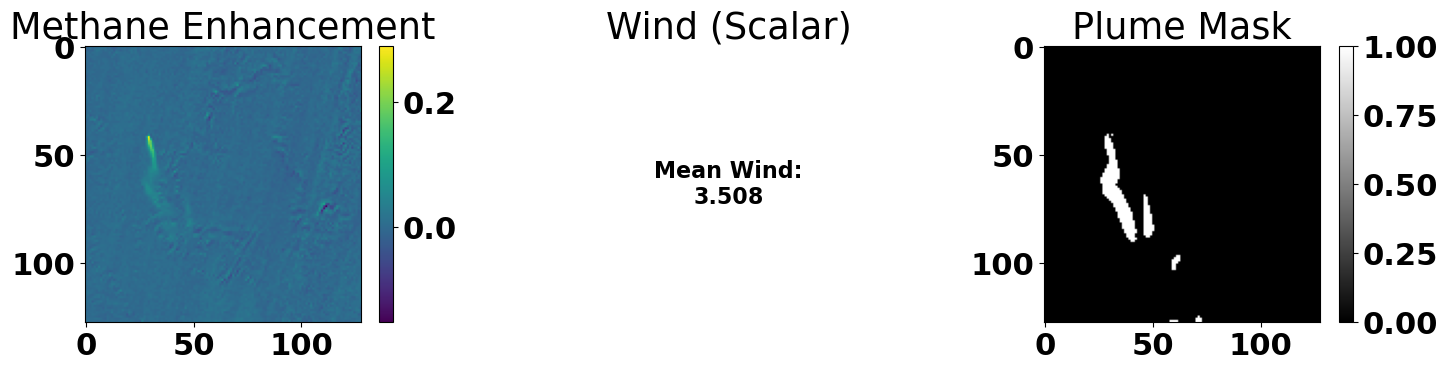

In [26]:
import matplotlib.pyplot as plt
import numpy as np

idx = 99  # Index of the sample to inspect

plt.figure(figsize=(15, 4))

# Channel 0: Methane enhancement
plt.subplot(1, 3, 1)
plt.imshow(imgs[idx, :, :, 0], cmap='viridis')
plt.title("Methane Enhancement")
plt.colorbar()

# Middle panel: Show scalar wind value (mean of channel 1)
plt.subplot(1, 3, 2)
mean_wind = np.mean(imgs[idx, :, :, 1])  # You can also try np.max or np.median
plt.axis('off')  # Hide axes
plt.text(0.5, 0.5, f"Mean Wind:\n{mean_wind:.3f}",
         fontsize=16, ha='center', va='center', transform=plt.gca().transAxes)
plt.title("Wind (Scalar)")

# Ground truth mask
plt.subplot(1, 3, 3)
plt.imshow(masks[idx], cmap='gray')
plt.title("Plume Mask")
plt.colorbar()

plt.tight_layout()
plt.show()


In [ ]:
#Once you have your formatted image and mask arrays the following line of code will randomly subset
#90% of them for training and 10% for testing. This ratio can be changed by altering the test_size
#parameter. The random_state command is set to 1 to allow for repeatability, but you can change
#or remove that parameter to get other potential subsets


x_train, x_test, y_train, y_test = train_test_split(
    imgs[:, :, :, 0:1],  # select only the enhancement channel, keep 4D shape
    masks,
    test_size=0.1,
    random_state=1
)
y_train = np.expand_dims(y_train, axis=-1)
y_test = np.expand_dims(y_test, axis=-1)


Okay now we create and train the model

In [ ]:
#Create model


#These two values should be set to the dimensions of your enhancement fields
#Altering these should be the only change needed in this cell

im_height = 128
im_width = 128
border = 5

input_img = Input((im_height, im_width,1), name='img')



model_mask = get_unet(input_img, n_filters=16, dropout=0.05, batchnorm=True)

model_mask.compile(optimizer=Adam(), loss=jaccard_coef_loss, metrics=["accuracy",jaccard_coef])
model_mask.summary()

In [ ]:
#Now that the model is built, we need to train it
#This cell will take a while to run depending on your training dimensions and image count
#I have set the number of epoch's to 10, but you should be able to go up to about 20 without overfitting


model_mask.fit(x_train, y_train, batch_size = 32, epochs = 10)

In [ ]:
#This takes your model and applies it over the test dataset to see how well it performs on data it
#Hasn't seen before


model_mask.evaluate(x_test,y_test)

In [ ]:
#You can save your trained model weights so you won't have to perform the training again
file_path = r"model_mask.keras"
model_mask.save(file_path)

In [ ]:
#And here is how to load those back in

model_mask.load_weights(file_path)

With the model now trained, you can use it to predict masks for batches of images. Remember, they must be of the model's defined input dimension

In [ ]:
#This line will produce predicted masks for all of the images in imgs
#Masks are not output as binary, but as confidence values between 0-1 for each pixel
#Threshold the masks at >0.5 for binary masking
#you can also use >0.75 or higher to be a little stricter

pred_masks = model_mask.predict(imgs[:, :, :, 0:1])


In [ ]:
#If you want to take a look at your performance for individual images we can mask out
#All the images in the test dataset, and compute their jaccard scores with the following

pred_masks_test = model_mask.predict(x_test)

jac_test = jac_simple(pred_masks_test[:,:,:,0:1]>0.5, y_test>0.5)

#You can then plot this jac test against different image characteristics (such as background std)
#To get an idea of how the model is performing in various conditions
#As a general rule of thumb Jaccard scores above 0.3 are quite good

In [ ]:
pred_masks = model_mask.predict(x_test)
binary_preds = (pred_masks > 0.5).astype(np.uint8)
for i in range(10):

# Choose an index to visualize
    idx = i

    # Predict (if not already done)
    #pred_masks = model_mask.predict(x_test)
    #binary_preds = (pred_masks > 0.5).astype(np.uint8)

    # Plot input, ground truth, and prediction
    plt.figure(figsize=(15, 4))

    # Input image (channel 0)
    plt.subplot(1, 3, 1)
    plt.title("Input (Enhancement)")
    plt.imshow(x_test[idx, :, :, 0], cmap='viridis')
    plt.colorbar()

    # Ground truth mask
    plt.subplot(1, 3, 2)
    plt.title("Ground Truth Mask")
    plt.imshow(y_test[idx, :, :, 0], cmap='gray')
    plt.colorbar()

    # Predicted mask
    plt.subplot(1, 3, 3)
    plt.title("Predicted Mask")
    plt.imshow(binary_preds[idx, :, :, 0], cmap='gray')
    plt.colorbar()

    plt.tight_layout()
    plt.show()


# Trying to get the CNN and IME to predict the value of the methane release

In [28]:
x_train, x_test, masks_train, masks_test = train_test_split(
    imgs[:, :, :, :2],  # ← grab channels 0 and 1 (enhancement + wind)
    masks,
    test_size=0.1,
    random_state=1
)


In [29]:
# Split the channels
enhancement_train = x_train[:, :, :, 0]
wind_train = x_train[:, :, :, 1]

enhancement_mean = np.mean(enhancement_train)
enhancement_std = np.std(enhancement_train)

wind_mean = np.mean(wind_train)
wind_std = np.std(wind_train)

# Normalize both channels separately
x_train_norm = np.empty_like(x_train)
x_test_norm = np.empty_like(x_test)

x_train_norm[:, :, :, 0] = (x_train[:, :, :, 0] - enhancement_mean) / enhancement_std
x_train_norm[:, :, :, 1] = (x_train[:, :, :, 1] - wind_mean) / wind_std

x_test_norm[:, :, :, 0] = (x_test[:, :, :, 0] - enhancement_mean) / enhancement_std
x_test_norm[:, :, :, 1] = (x_test[:, :, :, 1] - wind_mean) / wind_std


In [30]:
source_rates = []

for i in range(len(x_train_norm)):
    enhancement = x_train[i, :, :, 0]  # don't use normalized here — keep it raw for physical calculations
    mask = masks_train[i]

    rate = get_source_rate(enhancement, mask, u10=2, v10=0)  # you can also get u10 from the wind image if you want

    if not np.isfinite(rate):
        rate = 0.0
    source_rates.append(rate)

y_train = np.array(source_rates).reshape(-1, 1)


/var/folders/sj/rh2rfdw10059tf3j96bb12jh0000gn/T/ipykernel_1385/3903328186.py:340: RuntimeWarning: divide by zero encountered in scalar divide
  Q = u_eff/L*IME/(10**3)*3600 #t/h
/var/folders/sj/rh2rfdw10059tf3j96bb12jh0000gn/T/ipykernel_1385/3903328186.py:340: RuntimeWarning: invalid value encountered in scalar multiply
  Q = u_eff/L*IME/(10**3)*3600 #t/h


In [31]:

input_img = Input((128, 128, 2))  # ← note the 2 here now
model_source = get_sr_cnn_deep(input_img, n_filters=16, dropout=0.05, batchnorm=True)

model_source.compile(optimizer=Adam(learning_rate=1e-4), loss='mse', metrics=['mae'])
model_source.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 2)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 128, 128, 16)   │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 128, 128, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │             

 Total params: 1,707,457 (6.51 MB)

 Trainable params: 1,705,473 (6.51 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [21]:
print(y_train.shape)
print(np.min(y_train), np.max(y_train))
print("Any NaNs?", np.any(np.isnan(y_train)))


print("Any NaNs?", np.isnan(x_train).any())
print("Any Infs?", np.isinf(x_train).any())
print("Min:", np.min(x_train), "Max:", np.max(x_train))



(6182, 1)
-3.26147827529261 3.3702886906865883
Any NaNs? False
Any NaNs? False
Any Infs? False
Min: -5.991879463195801 Max: 4.639042418209622


In [32]:
history = model_source.fit(
    x_train_norm, y_train,
    batch_size=32,
    epochs=50
)


Epoch 1/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 68s 338ms/step - loss: 0.4987 - mae: 0.5372
Epoch 2/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 67s 344ms/step - loss: 0.2879 - mae: 0.4262
Epoch 3/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 64s 329ms/step - loss: 0.2553 - mae: 0.4050
Epoch 4/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 68s 349ms/step - loss: 0.2359 - mae: 0.3891
Epoch 5/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 65s 337ms/step - loss: 0.2195 - mae: 0.3667
Epoch 6/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 66s 340ms/step - loss: 0.1955 - mae: 0.3510
Epoch 7/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 68s 351ms/step - loss: 0.1861 - mae: 0.3443
Epoch 8/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 70s 361ms/step - loss: 0.1715 - mae: 0.3239
Epoch 9/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 64s 329ms/step - loss: 0.1630 - mae: 0.3179
Epoch 10/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 61s 314ms/step - loss: 0.1511 - mae: 0.3035
Epoch 11/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 59s 306ms/step - loss: 0.1386 - mae: 0.2916
Epoch 12/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 59s 306ms/step - loss: 0.1273 - m

In [33]:
source_rates_test = []

for i in range(len(x_test)):
    enhancement = x_test[i, :, :, 0]
    mask = masks_test[i]

    rate = get_source_rate(enhancement, mask, u10=2, v10=0)

    if not np.isfinite(rate):
        rate = 0.0
    source_rates_test.append(rate)

y_test = np.array(source_rates_test).reshape(-1, 1)


/var/folders/sj/rh2rfdw10059tf3j96bb12jh0000gn/T/ipykernel_1385/3903328186.py:340: RuntimeWarning: divide by zero encountered in scalar divide
  Q = u_eff/L*IME/(10**3)*3600 #t/h
/var/folders/sj/rh2rfdw10059tf3j96bb12jh0000gn/T/ipykernel_1385/3903328186.py:340: RuntimeWarning: invalid value encountered in scalar multiply
  Q = u_eff/L*IME/(10**3)*3600 #t/h


In [34]:
y_pred = model_source.predict(x_test)


22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step


In [35]:
for i in range(10):
    print(f"Sample {i}:")
    print(f"  True:     {y_test[i][0]:.2f}")
    print(f"  Predicted:{y_pred[i][0]:.2f}")
    print()


Sample 0:
  True:     1.19
  Predicted:0.36

Sample 1:
  True:     1.23
  Predicted:0.38

Sample 2:
  True:     1.98
  Predicted:0.37

Sample 3:
  True:     0.78
  Predicted:0.40

Sample 4:
  True:     1.15
  Predicted:0.45

Sample 5:
  True:     0.41
  Predicted:0.52

Sample 6:
  True:     1.02
  Predicted:0.43

Sample 7:
  True:     1.29
  Predicted:0.48

Sample 8:
  True:     0.58
  Predicted:0.38

Sample 9:
  True:     0.77
  Predicted:0.53



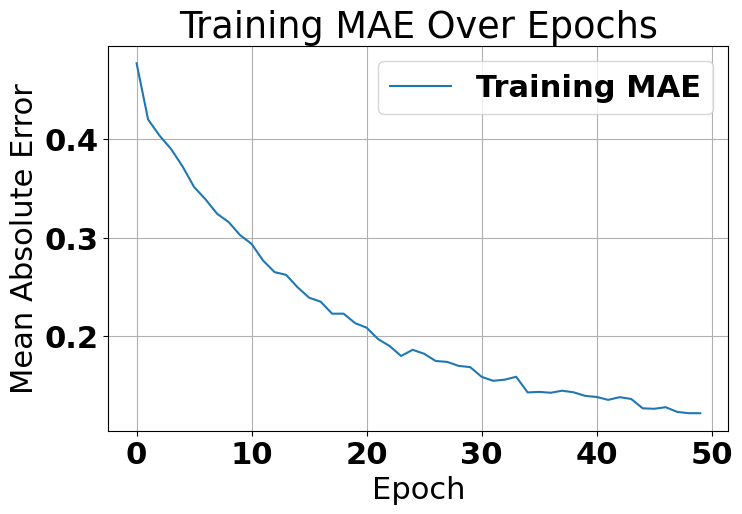

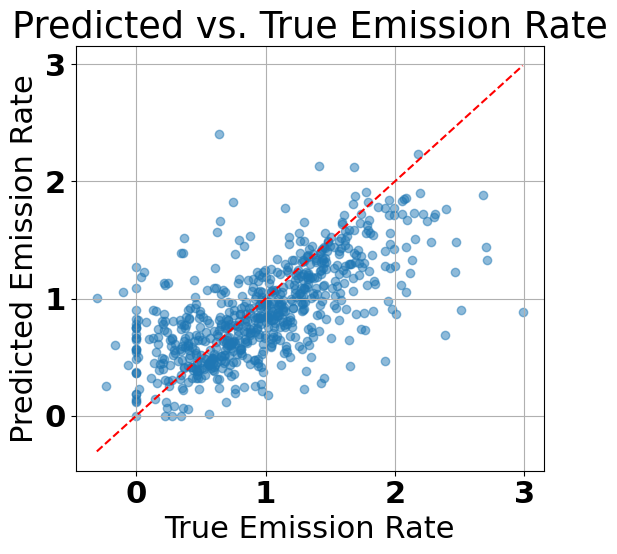

In [41]:
import matplotlib.pyplot as plt

# Plot MAE over epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history['mae'], label='Training MAE')
plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Error")
plt.title("Training MAE Over Epochs")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("True Emission Rate")
plt.ylabel("Predicted Emission Rate")
plt.title("Predicted vs. True Emission Rate")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 1:1 line
plt.grid(True)
plt.tight_layout()
plt.show()


